# Problem Statement 
The goal of this project is to analyze historical retail sales data and forecast future sales using Time Series Analysis techniques to support better business planning and decision-making.

## Part 1: Project Objectives

The main objectives of this project are:

- Analyze historical retail sales data.
- Identify trends, seasonality, and underlying patterns in sales.
- Perform Stationarity Analysis to evaluate the statistical properties of the time series.
- Apply Differencing techniques to achieve stationarity when required.
- Use Box-Cox Transformation to stabilize variance and improve model performance.
- Perform Time Series Decomposition to understand trend, seasonal, and residual components.
- Build forecasting models using AR , ARIMA and SARIMA.
- Evaluate model performance using forecasting metrics such as RMSE and MAE

### Project Workflow

1. Project Objective
2. Data Loading and Inspection
3. Data Cleaning and Preprocessing
4. Exploratory Data Analysis (EDA)
5. Stationarity Analysis
6. Time Series Transformation
7. Time Series Decomposition
8. Autocorrelation Plots (ACF & PACF)
9. Autoregressive Model (AR)
10. ARIMA Modeling
11. SARIMA Modeling
12. Model Evaluation & Comparison
13. Conclusion

## Dataset Description
The dataset contains historical retail sales transactions collected from a retail business.

### Key Features

- Order Date: Date when the order was placed.
- Sales: Revenue generated from the order.
- Profit: Profit earned from the order.

### Target Variable

The primary target variable for this project is:

- Sales
The Sales variable will be analyzed and forecasted using Time Series Forecasting techniques.


# Part 2: Data Loading and Inspection
In this section, we load the dataset and perform an initial inspection to identify data types, missing values, and overall dataset information.

In [1]:
import pandas as pd
import numpy as np

import matplotlib as mlt
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', ConvergenceWarning)

In [2]:
# Loading Dataset
data = pd.read_csv('Superstore_Data.csv')
data.head()

,Order Date,Sales,Profit
0,17-10-2013,5175.171,919.971
1,07-11-2011,1822.080,564.840
2,14-04-2012,5244.840,996.480
3,06-06-2013,3701.520,1036.080
4,25-02-2012,1878.720,582.360


In [3]:
# Dataset Shape
data.shape

(5699, 3)

In [4]:
# Dataset Information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5699 entries, 0 to 5698
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order Date  5699 non-null   object 
 1   Sales       5699 non-null   float64
 2   Profit      5699 non-null   float64
dtypes: float64(2), object(1)
memory usage: 133.7+ KB


In [5]:
# Statistical Summary
data.describe()

,Sales,Profit
count,5699.000000,5699.000000
mean,318.784646,39.097659
std,540.272454,164.472190
min,2.880000,-2380.350000
25%,46.542600,-2.877600
50%,121.920000,10.800000
75%,341.898300,46.800000
max,5759.964000,2817.990000


# Part 3: Data Cleaning and Preprocessing

Data preprocessing is a crucial step before performing Time Series Analysis.

In this section, we will:

- Check for missing values
- Check for duplicate records
- Convert date columns into datetime format
- Sort the data chronologically
- Prepare the dataset for time series analysis

In [6]:
# Checking Missing Values
data.isnull().sum()

Order Date    0
Sales         0
Profit        0
dtype: int64

In [7]:
# Checking Duplicate Records
data.duplicated().sum()

np.int64(3)

In [8]:
# Converting Order Date into Datetime Format
data['Order Date'] = pd.to_datetime(data['Order Date'])

In [9]:
data.head()

,Order Date,Sales,Profit
0,2013-10-17,5175.171,919.971
1,2011-11-07,1822.080,564.840
2,2012-04-14,5244.840,996.480
3,2013-06-06,3701.520,1036.080
4,2012-02-25,1878.720,582.360


In [10]:
# Sorting Dataset by Date
data = data.sort_values('Order Date')

In [11]:
data.head()

,Order Date,Sales,Profit
5073,2011-01-01,55.242,15.342
3056,2011-01-01,120.366,36.036
4083,2011-01-01,113.670,37.770
424,2011-01-03,912.456,-319.464
5517,2011-01-03,6.006,0.546


In [12]:
# Verifying Datatype
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5699 entries, 5073 to 3956
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  5699 non-null   datetime64[ns]
 1   Sales       5699 non-null   float64       
 2   Profit      5699 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 178.1 KB


# Part 4: Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the underlying patterns, trends, and distribution of the data before building forecasting models.

In this section, we will:

- Analyze sales and profit distributions
- Study sales trends over time
- Identify seasonal patterns
- Detect unusual spikes or anomalies
- Generate business insights from historical data

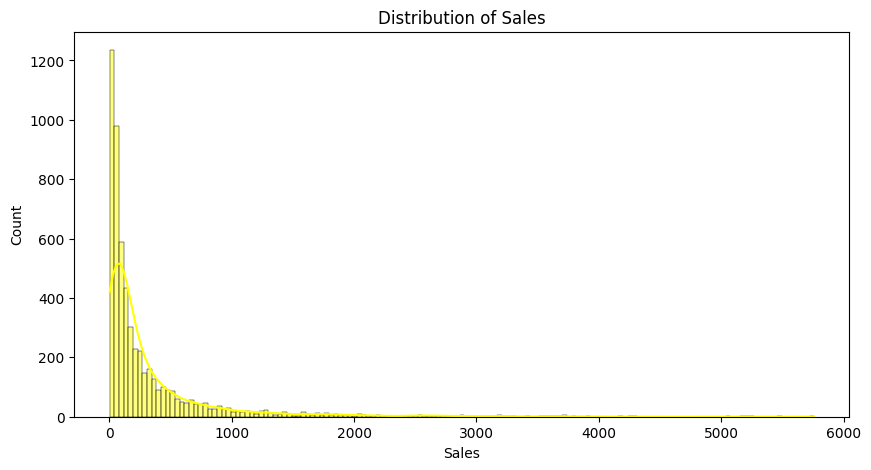

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(data['Sales'], kde=True,color = 'yellow')
plt.title('Distribution of Sales')
plt.show()

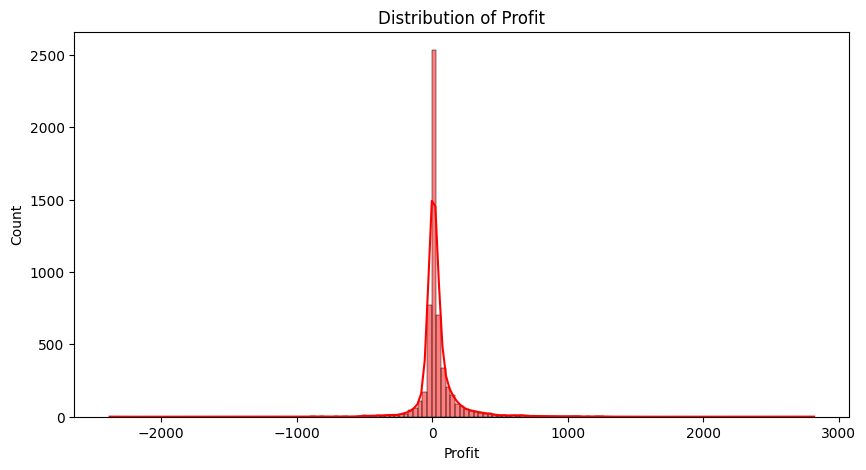

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(data['Profit'], kde=True,color = 'red')
plt.title('Distribution of Profit')
plt.show()

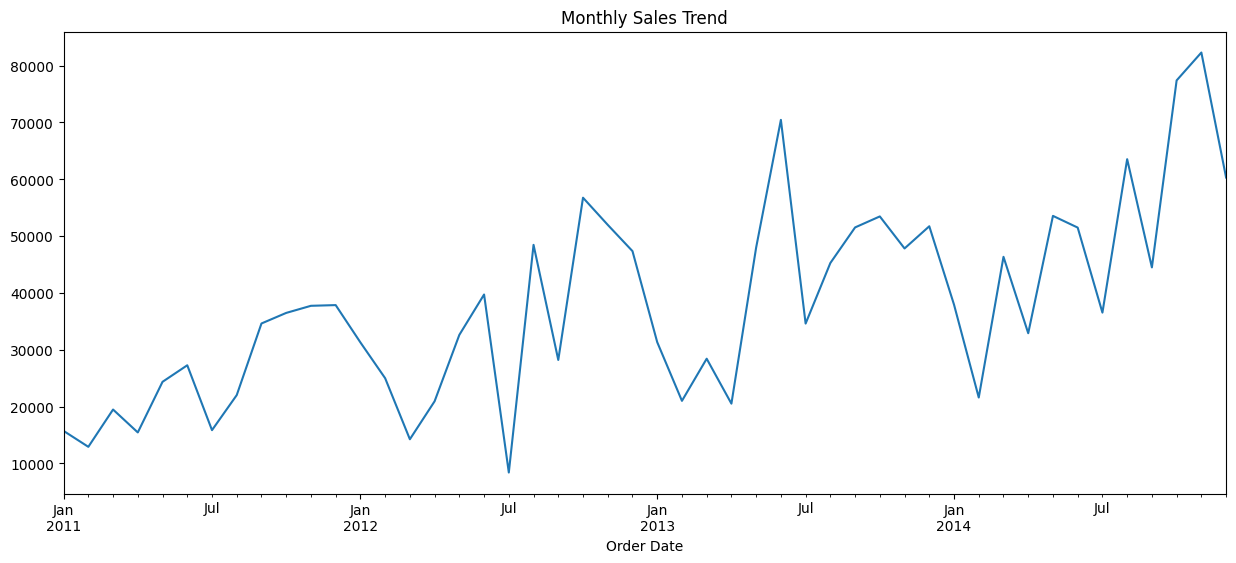

In [15]:
monthly_sales = data.groupby(
    pd.Grouper(key='Order Date', freq='M')
)['Sales'].sum()

monthly_sales.plot(figsize=(15,6))
plt.title('Monthly Sales Trend')
plt.show()

In [16]:
data.sample()

,Order Date,Sales,Profit
3191,2013-02-14,40.095,-3.255


In [17]:
data.reset_index(inplace = True)
data.head()

,index,Order Date,Sales,Profit
0,5073,2011-01-01,55.242,15.342
1,3056,2011-01-01,120.366,36.036
2,4083,2011-01-01,113.670,37.770
3,424,2011-01-03,912.456,-319.464
4,5517,2011-01-03,6.006,0.546


In [18]:
data.drop(columns = "index",inplace = True)
data.head()

,Order Date,Sales,Profit
0,2011-01-01,55.242,15.342
1,2011-01-01,120.366,36.036
2,2011-01-01,113.670,37.770
3,2011-01-03,912.456,-319.464
4,2011-01-03,6.006,0.546


In [19]:
data.head(2)

,Order Date,Sales,Profit
0,2011-01-01,55.242,15.342
1,2011-01-01,120.366,36.036


## Creating a Time Series Index

For time series analysis, the date column should be used as the index because all observations are analyzed with respect to time.

In this step:

- The unnecessary index column will be removed.
- Order Date will be set as the DataFrame index.
- The dataset will be sorted chronologically.

In [20]:
# Setting Order Date as index
data.set_index('Order Date', inplace=True)

In [21]:
data.head()

,Sales,Profit
Order Date,,
2011-01-01,55.242,15.342
2011-01-01,120.366,36.036
2011-01-01,113.670,37.770
2011-01-03,912.456,-319.464
2011-01-03,6.006,0.546


In [22]:
# Sorting data chronologically

data.sort_index(inplace=True)
data.head(10)

,Sales,Profit
Order Date,,
2011-01-01,55.2420,15.3420
2011-01-01,120.3660,36.0360
2011-01-01,113.6700,37.7700
2011-01-03,912.4560,-319.4640
2011-01-03,6.0060,0.5460
2011-01-03,159.4440,-95.6760
2011-01-03,135.1182,-45.9018
2011-01-03,211.1805,-70.3995
2011-01-03,69.3000,3.4200


In [23]:
data = data.groupby(pd.Grouper(freq = 'M')).sum()
data

,Sales,Profit
Order Date,,
2011-01-31,15711.7125,991.2825
2011-02-28,12910.8588,1338.8688
2011-03-31,19472.5632,3747.1632
2011-04-30,15440.3046,3846.4746
2011-05-31,24348.9723,3639.9423
2011-06-30,27260.0196,4328.2596
2011-07-31,15842.8317,1258.9617
2011-08-31,22012.2366,775.8066
2011-09-30,34613.1849,5181.4449


In [24]:
data.shape

(48, 2)

In [25]:
data.drop(columns = "Profit",inplace = True)
data.head(3)

,Sales
Order Date,
2011-01-31,15711.7125
2011-02-28,12910.8588
2011-03-31,19472.5632


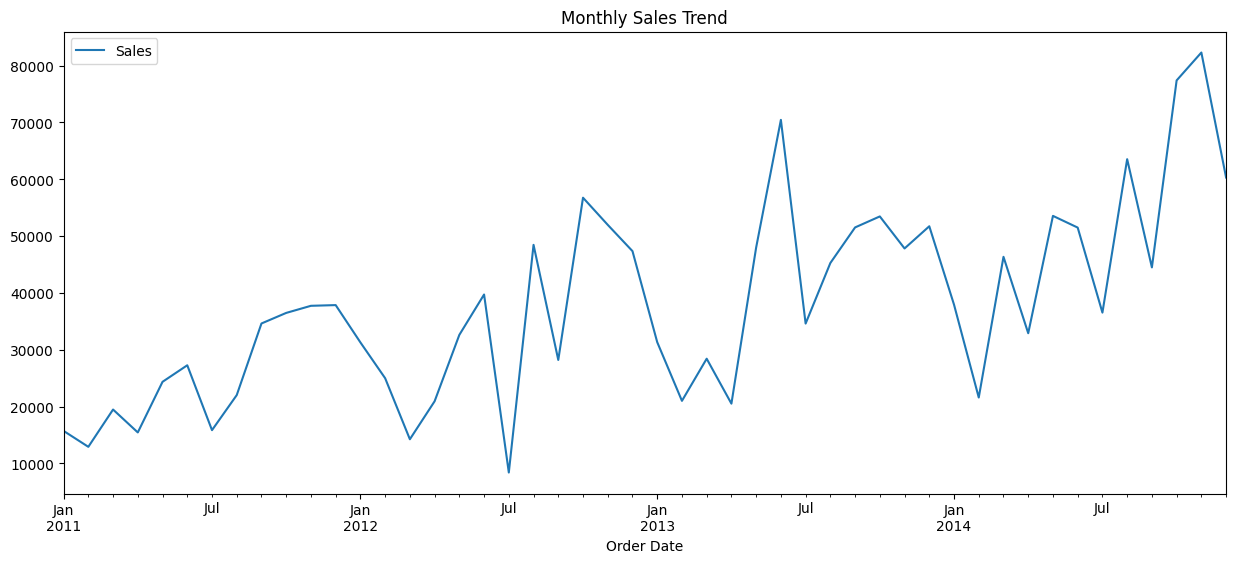

In [26]:
data.plot(figsize=(15,6))
plt.title('Monthly Sales Trend')
plt.show()

# Part 5: Stationarity Analysis

Before building forecasting models such as ARIMA and SARIMA, it is important to determine whether the time series is stationary.

A stationary time series has:

- Constant Mean
- Constant Variance
- Constant Autocorrelation Structure

Most statistical forecasting models assume stationarity. Therefore, we must verify whether the sales time series satisfies this assumption.

## Augmented Dickey-Fuller (ADF) Test

In [27]:
from statsmodels.tsa.stattools import adfuller

In [28]:
# Performing ADF Test
result = adfuller(data['Sales'])
#print('ADF Statistic :', result[0])
print('p-value :', result[1])
#print('Number of Lags :', result[2])
#print('Number of Observations :', result[3])

p-value : 0.1987628396941693


If the $p$-value is < $0.05$, then our data is stationary otherwise our data is non-stationary

In our case our data is not stationary as the p- value is greater than 5%

# Part 6: Time Series Transformation

The stationarity analysis indicated that the original time series is non-stationary.

To prepare the data for forecasting models such as ARIMA and SARIMA, transformation techniques are applied.

The objective of these transformations is to:

- Stabilize the mean
- Stabilize the variance
- Achieve stationarity

The following transformation techniques will be used:

1. Box-Cox Transformation
2. First Order Differencing

In [29]:
df_train = data[0:42] #first 42 rows for training
df_test = data[42:] #last 6 rows for testing

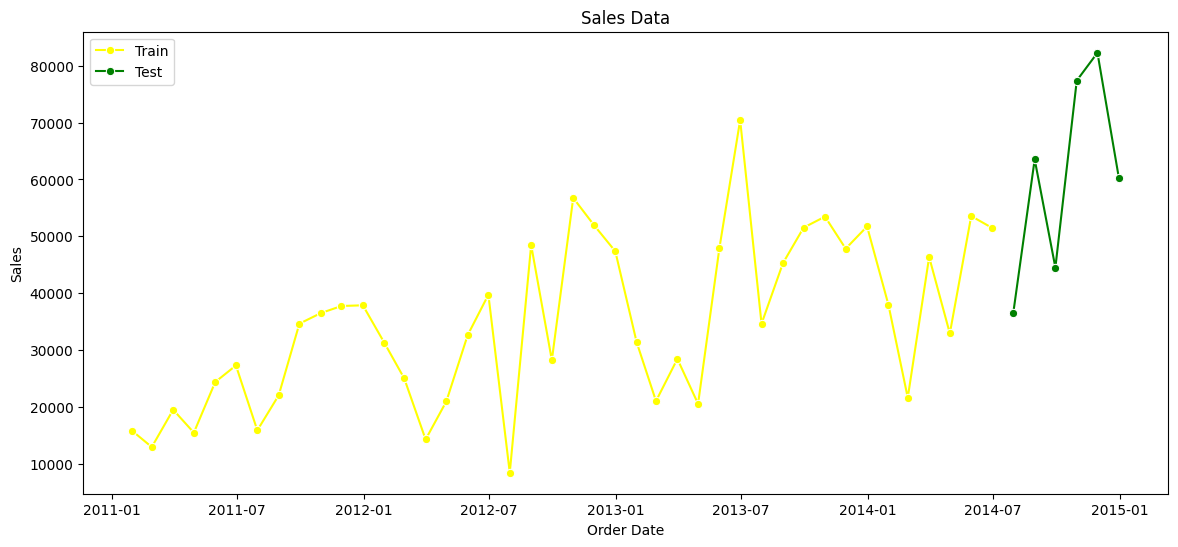

In [30]:
# Plot the time series data with the train-test split
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train, x = 'Order Date', y = 'Sales', marker = 'o', color = 'yellow', label = 'Train')
sns.lineplot(data = df_test, x = 'Order Date', y = 'Sales', marker = 'o', color = 'green', label = 'Test')
plt.title('Sales Data');

# Subpart 1 - Box-Cox Transformation

In [31]:
# Import the 'boxcox' method from 'scipy' to implement the Box-Cox transformation
from scipy.stats import boxcox

In [32]:
#we transformed the sales column with BCT and store the transformed version in the df_boxcox variable
df_boxcox = pd.Series(boxcox(df_train['Sales'], lmbda = 0), index = df_train.index)

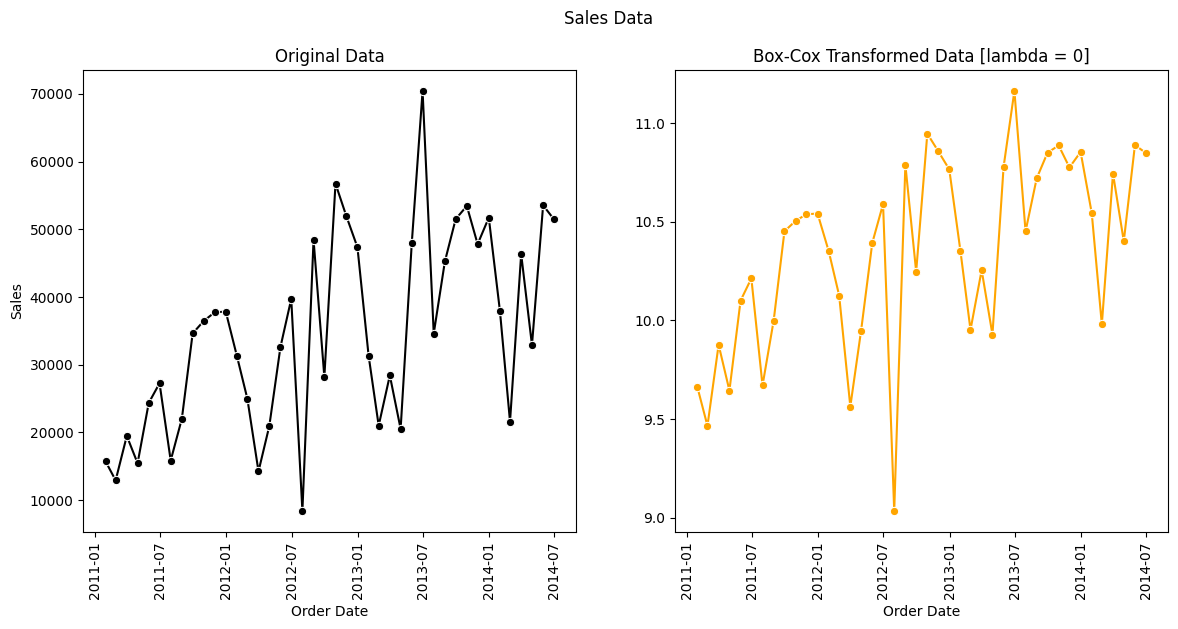

In [33]:
# Plot the original time series data and its Box-Cox transformed version
plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data = df_train, x = 'Order Date', y = 'Sales', marker = 'o', color = 'black')
plt.xticks(rotation = 90)
plt.title('Original Data')

plt.subplot(1, 2, 2)
sns.lineplot(x = df_boxcox.index, y = df_boxcox.values, marker = 'o', color = 'orange')
plt.xticks(rotation = 90)
plt.title('Box-Cox Transformed Data [lambda = 0]')

plt.suptitle('Sales Data');

In [34]:
df_boxcox

Order Date
2011-01-31     9.662162
2011-02-28     9.465824
2011-03-31     9.876762
2011-04-30     9.644737
2011-05-31    10.100245
2011-06-30    10.213176
2011-07-31     9.670472
2011-08-31     9.999354
2011-09-30    10.451990
2011-10-31    10.504301
2011-11-30    10.538015
2011-12-31    10.541307
2012-01-31    10.350762
2012-02-29    10.126058
2012-03-31     9.563893
2012-04-30     9.948770
2012-05-31    10.392332
2012-06-30    10.589359
2012-07-31     9.034764
2012-08-31    10.788180
2012-09-30    10.246837
2012-10-31    10.946289
2012-11-30    10.858364
2012-12-31    10.765187
2013-01-31    10.352276
2013-02-28     9.952265
2013-03-31    10.254659
2013-04-30     9.928605
2013-05-31    10.778531
2013-06-30    11.162471
2013-07-31    10.451517
2013-08-31    10.719994
2013-09-30    10.849594
2013-10-31    10.886475
2013-11-30    10.775048
2013-12-31    10.853554
2014-01-31    10.543348
2014-02-28     9.979731
2014-03-31    10.743763
2014-04-30    10.401152
2014-05-31    10.888275
2014-

# Subpart 2 - Differencing
Differencing is used to stabilize the mean of a time series.

In [35]:
df_differenced = df_train['Sales'].diff()
#df_differenced.diff()

In [36]:
df_differenced

Order Date
2011-01-31           NaN
2011-02-28    -2800.8537
2011-03-31     6561.7044
2011-04-30    -4032.2586
2011-05-31     8908.6677
2011-06-30     2911.0473
2011-07-31   -11417.1879
2011-08-31     6169.4049
2011-09-30    12600.9483
2011-10-31     1858.8621
2011-11-30     1250.5569
2011-12-31      124.3872
2012-01-31    -6566.1276
2012-02-29    -6295.1754
2012-03-31   -10744.5120
2012-04-30     6685.2960
2012-05-31    11682.1491
2012-06-30     7101.4140
2012-07-31   -31320.3036
2012-08-31    40055.0661
2012-09-30   -20251.5741
2012-10-31    28549.8597
2012-11-30    -4776.0693
2012-12-31    -4623.3873
2013-01-31   -16015.3647
2013-02-28   -10328.5242
2013-03-31     7414.8831
2013-04-30    -7905.9012
2013-05-31    27470.8803
2013-06-30    22457.2089
2013-07-31   -35839.9842
2013-08-31    10654.8192
2013-09-30     6261.5796
2013-10-31     1935.3297
2013-11-30    -5635.7748
2013-12-31     3904.8420
2014-01-31   -13793.2908
2014-02-28   -16339.8210
2014-03-31    24755.6010
2014-04-30   -

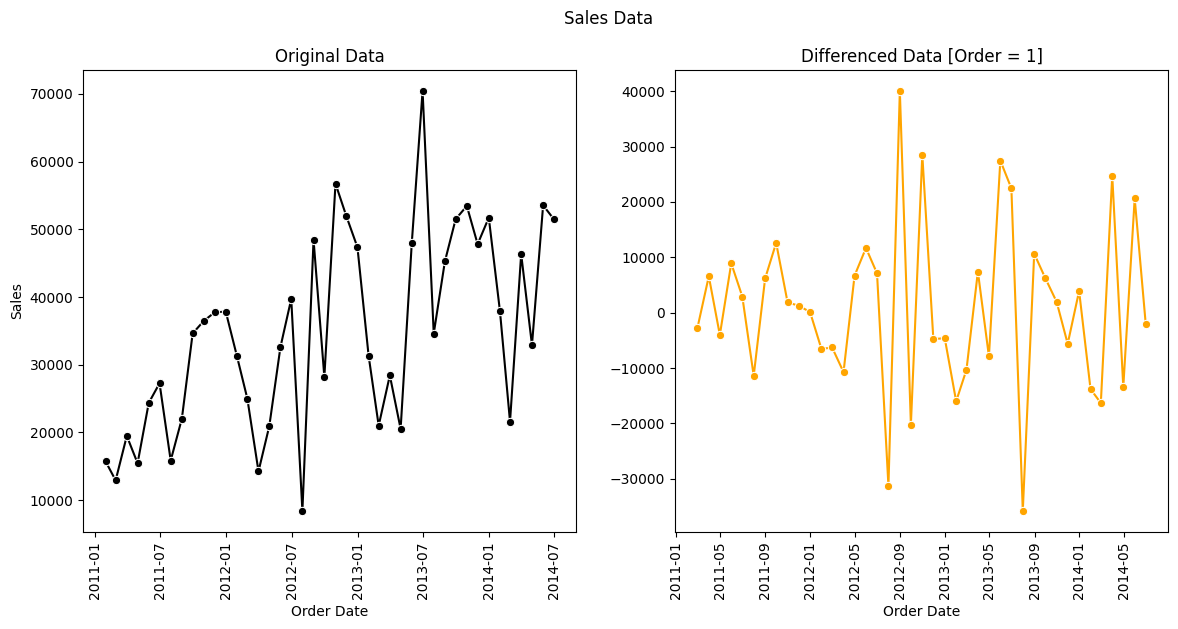

In [37]:
# Plot the original time series data and its first-order differenced version
plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data = df_train, x = 'Order Date', y = 'Sales', marker = 'o', color = 'black')
plt.xticks(rotation = 90)
plt.title('Original Data')

plt.subplot(1, 2, 2)
sns.lineplot(x = df_differenced.index, y = df_differenced.values, marker = 'o', color = 'orange')
plt.xticks(rotation = 90)
plt.title('Differenced Data [Order = 1]')

plt.suptitle('Sales Data');

# Subpart 3 - Differencing + Box Cox Tranformation
We will now apply the Box-Cox and the differencing transformations on the training data so that the data is ready for autoregressive time series modeling.

In [38]:
df_boxcox = pd.Series(boxcox(df_train['Sales'], lmbda = 0), index = df_train.index)
df_boxcox_diff = df_boxcox.diff()

In [39]:
df_boxcox

Order Date
2011-01-31     9.662162
2011-02-28     9.465824
2011-03-31     9.876762
2011-04-30     9.644737
2011-05-31    10.100245
2011-06-30    10.213176
2011-07-31     9.670472
2011-08-31     9.999354
2011-09-30    10.451990
2011-10-31    10.504301
2011-11-30    10.538015
2011-12-31    10.541307
2012-01-31    10.350762
2012-02-29    10.126058
2012-03-31     9.563893
2012-04-30     9.948770
2012-05-31    10.392332
2012-06-30    10.589359
2012-07-31     9.034764
2012-08-31    10.788180
2012-09-30    10.246837
2012-10-31    10.946289
2012-11-30    10.858364
2012-12-31    10.765187
2013-01-31    10.352276
2013-02-28     9.952265
2013-03-31    10.254659
2013-04-30     9.928605
2013-05-31    10.778531
2013-06-30    11.162471
2013-07-31    10.451517
2013-08-31    10.719994
2013-09-30    10.849594
2013-10-31    10.886475
2013-11-30    10.775048
2013-12-31    10.853554
2014-01-31    10.543348
2014-02-28     9.979731
2014-03-31    10.743763
2014-04-30    10.401152
2014-05-31    10.888275
2014-

In [40]:
df_boxcox_diff

Order Date
2011-01-31         NaN
2011-02-28   -0.196338
2011-03-31    0.410938
2011-04-30   -0.232025
2011-05-31    0.455508
2011-06-30    0.112932
2011-07-31   -0.542704
2011-08-31    0.328881
2011-09-30    0.452636
2011-10-31    0.052311
2011-11-30    0.033713
2011-12-31    0.003292
2012-01-31   -0.190545
2012-02-29   -0.224703
2012-03-31   -0.562166
2012-04-30    0.384877
2012-05-31    0.443562
2012-06-30    0.197027
2012-07-31   -1.554595
2012-08-31    1.753416
2012-09-30   -0.541343
2012-10-31    0.699452
2012-11-30   -0.087925
2012-12-31   -0.093177
2013-01-31   -0.412912
2013-02-28   -0.400011
2013-03-31    0.302394
2013-04-30   -0.326054
2013-05-31    0.849926
2013-06-30    0.383940
2013-07-31   -0.710954
2013-08-31    0.268477
2013-09-30    0.129600
2013-10-31    0.036881
2013-11-30   -0.111427
2013-12-31    0.078506
2014-01-31   -0.310206
2014-02-28   -0.563617
2014-03-31    0.764032
2014-04-30   -0.342611
2014-05-31    0.487122
2014-06-30   -0.039254
Freq: ME, dtype: float6

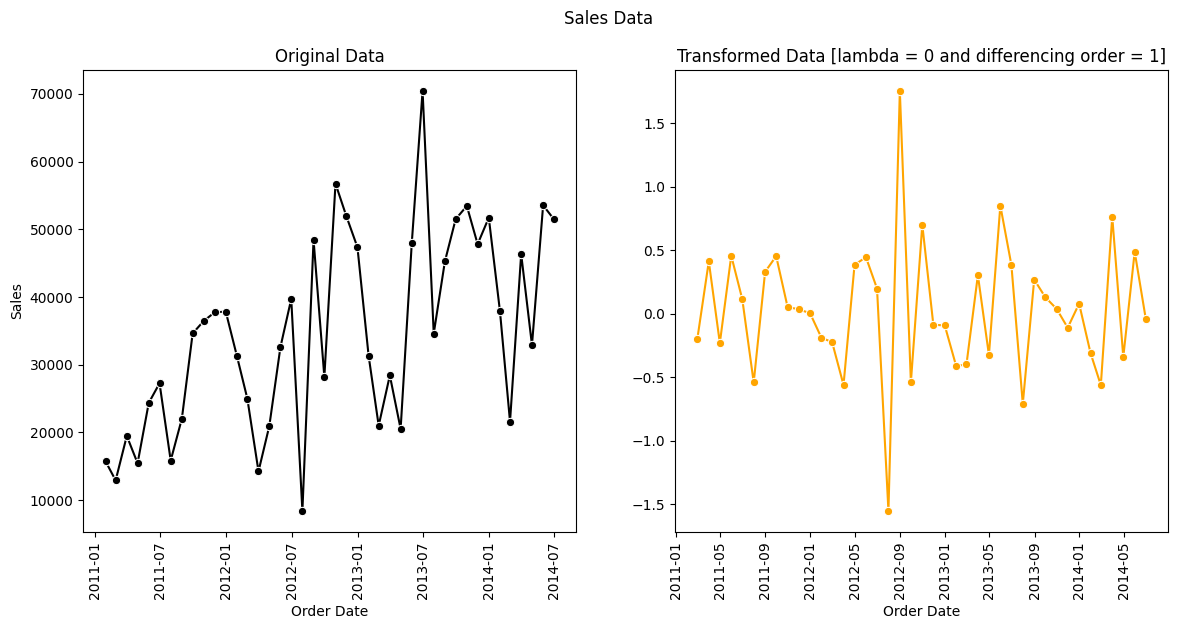

In [41]:
# Plot the original time series data and its transformed version
plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data = df_train, x = 'Order Date', y = 'Sales', marker = 'o', color = 'black')
plt.xticks(rotation = 90)
plt.title('Original Data')

plt.subplot(1, 2, 2)
sns.lineplot(x = df_boxcox_diff.index, y = df_boxcox_diff.values, marker = 'o', color = 'orange')
plt.xticks(rotation = 90)
plt.title('Transformed Data [lambda = 0 and differencing order = 1]')

plt.suptitle('Sales Data');

## Run the Adfuller test on the data, again after transformation to check whether our data has become stationary or not.
- we take `df_boxcox_diff[1:]` because the first value is null so we are ignoring the first value and running the test on the rest of the values.

In [42]:
result_after_transformation = adfuller(df_boxcox_diff[1:])

In [43]:
result_after_transformation[1]
#p_value of adfuller test after transformation

np.float64(7.4522117377526295e-06)

In [44]:
result = adfuller(df_boxcox_diff[1:])

print("ADF Statistic :", result[0])
print("p-value :", result[1])

ADF Statistic : -5.235081428404384
p-value : 7.4522117377526295e-06


The ADF test produced a p-value of 0.00000745, confirming that the transformed series is stationary and ready for time series modeling.

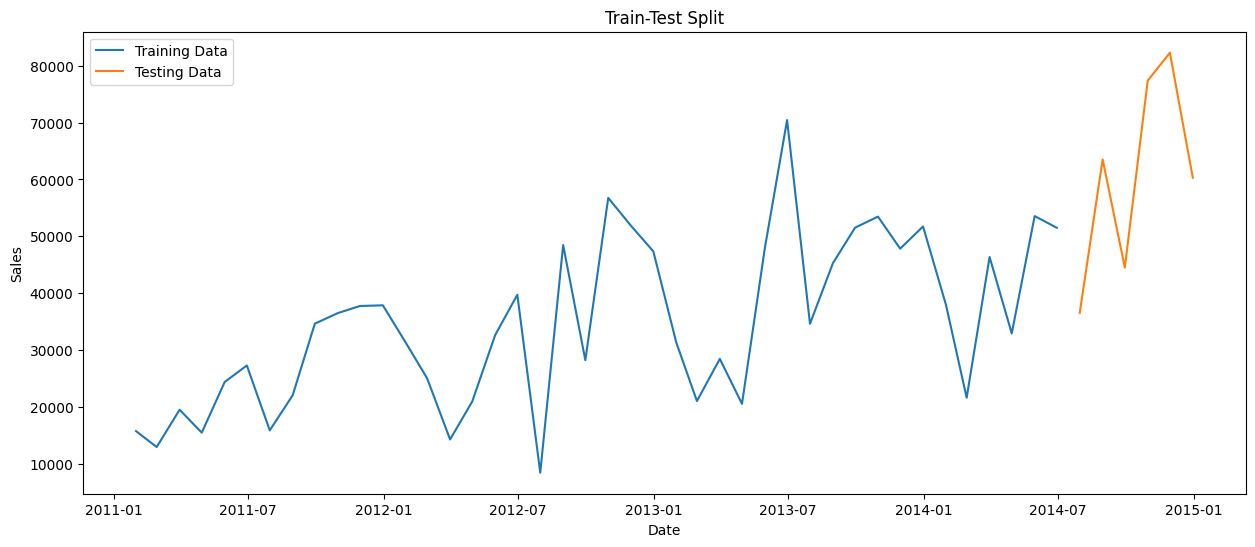

In [45]:
plt.figure(figsize=(15,6))

plt.plot(df_train, label='Training Data')

plt.plot(df_test, label='Testing Data')

plt.title('Train-Test Split')

plt.xlabel('Date')
plt.ylabel('Sales')

plt.legend()

plt.show()

# Part 7: Time Series Decomposition

Time Series Decomposition helps break a time series into its fundamental components:

- Trend
- Seasonality
- Residual

#### **1. Seasonal Decomposition of the data before transformation**

In [46]:
from statsmodels.tsa.seasonal import seasonal_decompose

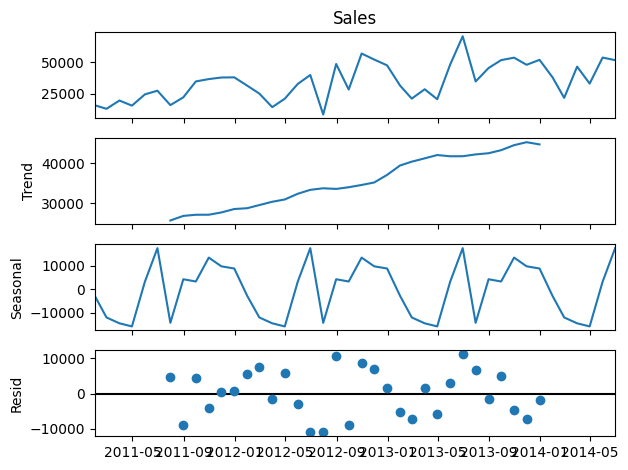

In [47]:
seasonal_decompose(df_train['Sales']).plot();

#### **2. Seasonal Decomposition of the data after transformation**

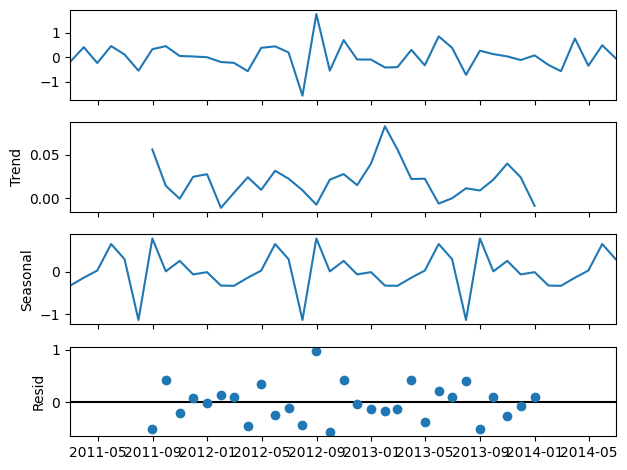

In [48]:
seasonal_decompose(df_boxcox_diff[1:]).plot();

# Part 8: Autocorrelation Plots (ACF & PACF)

After transforming the time series into a stationary series, Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots are analyzed.

These plots help identify the appropriate parameters for ARIMA and SARIMA models.

Specifically:

- ACF helps estimate the Moving Average (MA) order (q)
- PACF helps estimate the AutoRegressive (AR) order (p)

These parameters are critical for building accurate forecasting models.

## 8.1 Autocorrelation Function (ACF)
It helps determine the appropriate Moving Average (MA) order for ARIMA models.

In [49]:
# Import 'plot_acf' from 'statsmodels' to compute and visualize the autocorrelation function (ACF) for the time series
from statsmodels.graphics.tsaplots import plot_acf

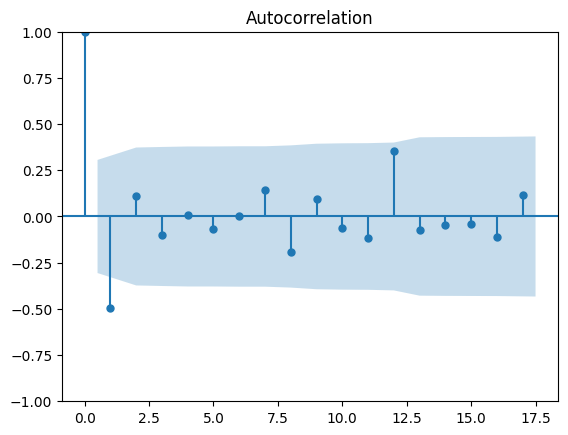

In [50]:
# Note: Since differencing results in a missing value at the beginning, we must exclude it
plot_acf(df_boxcox_diff[1:]);

## 8.2 Partial Autocorrelation Function (PACF)
It helps determine the appropriate AutoRegressive (AR) order for ARIMA models.

In [51]:
# Import 'plot_pacf' from 'statsmodels' to compute and visualize the partial autocorrelation function (ACF) for the time series
from statsmodels.graphics.tsaplots import plot_pacf

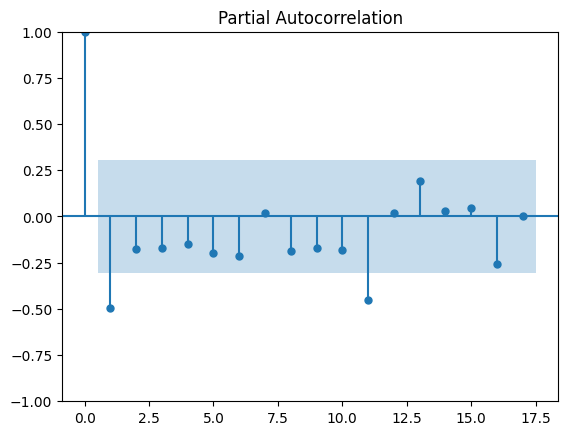

In [52]:
# Note: Since differencing results in a missing value at the beginning, we must exclude it
plot_pacf(df_boxcox_diff[1:]);

## Interpretation

The significant spikes observed in the ACF and PACF plots provide guidance for selecting the ARIMA parameters:

- p → Identified using the PACF plot
- q → Identified using the ACF plot
- d → Obtained from the differencing step

These values will be used in the upcoming ARIMA and SARIMA modeling sections.

- ACF helps estimate the MA(q) component.
- PACF helps estimate the AR(p) component.

# Part 9: Autoregressive Model (AR)
We will begin by fitting a basic autoregressive model to the training data and analyze its performance. We will use the ARIMA method from statsmodels to build the model.

In [53]:
# Import 'ARIMA' from 'statsmodels' for building autoregressive models
from statsmodels.tsa.arima.model import ARIMA

In [54]:
# Fit an AR model to the transformed training data with lag order 1 and view its optimal parameter values
ar_model = ARIMA(df_boxcox_diff, order = (1, 0, 0))
ar_model = ar_model.fit()

In [55]:
ar_model

In [56]:
# Obtain predictions from the AR model for the testing data indices
train_len = 42
test = []
for i in range(train_len,len(data)):
    test.append(i)

print(test)
ar_model_pred = ar_model.forecast(len(test))
ar_model_pred
#ar_forecast = ar_model.forecast(steps = len(test)+1)
#ar_model_preds = ar_model.predict(start = train_len, end = len(data)-1)

[42, 43, 44, 45, 46, 47]


2014-07-31    0.065469
2014-08-31    0.014786
2014-09-30    0.039315
2014-10-31    0.027443
2014-11-30    0.033189
2014-12-31    0.030408
Freq: ME, Name: predicted_mean, dtype: float64

In [57]:
ar_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   42
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 -26.509
Date:                Wed, 17 Jun 2026   AIC                             59.017
Time:                        11:04:16   BIC                             64.230
Sample:                    01-31-2011   HQIC                            60.928
                         - 06-30-2014                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0313      0.056      0.562      0.574      -0.078       0.140
ar.L1         -0.4840      0.124     -3.897      0.000      -0.727      -0.241
sigma2         0.2120      0.043      4.919      0.000       0.128       0.296
===================================================================================
Ljung-Box (L1) (Q):                   0.39   Jarque-Bera (JB):                 6.63
Prob(Q):                              0.53   Prob(JB):                         0.04
Heteroskedasticity (H):               2.08   Skew:                            -0.70
Prob(H) (two-sided):                  0.18   Kurtosis:                         4.36
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [58]:
df_test

,Sales
Order Date,
2014-07-31,36524.3028
2014-08-31,63521.7729
2014-09-30,44477.2662
2014-10-31,77379.8286
2014-11-30,82286.3583
2014-12-31,60292.1310


In [59]:
# Append the predictions with 'df_boxcox_diff' to prepare the data for inverse transformation
df_boxcox_diff_pred_ar = pd.concat([df_boxcox_diff, ar_model_pred])
df_boxcox_diff_pred_ar

2011-01-31         NaN
2011-02-28   -0.196338
2011-03-31    0.410938
2011-04-30   -0.232025
2011-05-31    0.455508
2011-06-30    0.112932
2011-07-31   -0.542704
2011-08-31    0.328881
2011-09-30    0.452636
2011-10-31    0.052311
2011-11-30    0.033713
2011-12-31    0.003292
2012-01-31   -0.190545
2012-02-29   -0.224703
2012-03-31   -0.562166
2012-04-30    0.384877
2012-05-31    0.443562
2012-06-30    0.197027
2012-07-31   -1.554595
2012-08-31    1.753416
2012-09-30   -0.541343
2012-10-31    0.699452
2012-11-30   -0.087925
2012-12-31   -0.093177
2013-01-31   -0.412912
2013-02-28   -0.400011
2013-03-31    0.302394
2013-04-30   -0.326054
2013-05-31    0.849926
2013-06-30    0.383940
2013-07-31   -0.710954
2013-08-31    0.268477
2013-09-30    0.129600
2013-10-31    0.036881
2013-11-30   -0.111427
2013-12-31    0.078506
2014-01-31   -0.310206
2014-02-28   -0.563617
2014-03-31    0.764032
2014-04-30   -0.342611
2014-05-31    0.487122
2014-06-30   -0.039254
2014-07-31    0.065469
2014-08-31 

In [60]:
# Reverse the differencing transformation that was done on the data
#df_boxcox_pred_ar = df_boxcox_diff_pred_ar.cumsum() #cummulative series
#df_boxcox_pred_ar = df_boxcox_diff_pred_ar.add(df_boxcox[0]) #initial value adjustment series


df_boxcox_pred_ar = df_boxcox_diff_pred_ar.cumsum()
df_boxcox_pred_ar = df_boxcox_pred_ar.add(df_boxcox[0])
df_boxcox_pred_ar.head()

2011-01-31          NaN
2011-02-28     9.465824
2011-03-31     9.876762
2011-04-30     9.644737
2011-05-31    10.100245
Freq: ME, dtype: float64

In [61]:
# Reverse the Box-Cox transformation that was done on the data
df_pred_ar = np.exp(df_boxcox_pred_ar)

In [62]:
df_pred_ar

2011-01-31             NaN
2011-02-28    12910.858800
2011-03-31    19472.563200
2011-04-30    15440.304600
2011-05-31    24348.972300
2011-06-30    27260.019600
2011-07-31    15842.831700
2011-08-31    22012.236600
2011-09-30    34613.184900
2011-10-31    36472.047000
2011-11-30    37722.603900
2011-12-31    37846.991100
2012-01-31    31280.863500
2012-02-29    24985.688100
2012-03-31    14241.176100
2012-04-30    20926.472100
2012-05-31    32608.621200
2012-06-30    39710.035200
2012-07-31     8389.731600
2012-08-31    48444.797700
2012-09-30    28193.223600
2012-10-31    56743.083300
2012-11-30    51967.014000
2012-12-31    47343.626700
2013-01-31    31328.262000
2013-02-28    20999.737800
2013-03-31    28414.620900
2013-04-30    20508.719700
2013-05-31    47979.600000
2013-06-30    70436.808900
2013-07-31    34596.824700
2013-08-31    45251.643900
2013-09-30    51513.223500
2013-10-31    53448.553200
2013-11-30    47812.778400
2013-12-31    51717.620400
2014-01-31    37924.329600
2

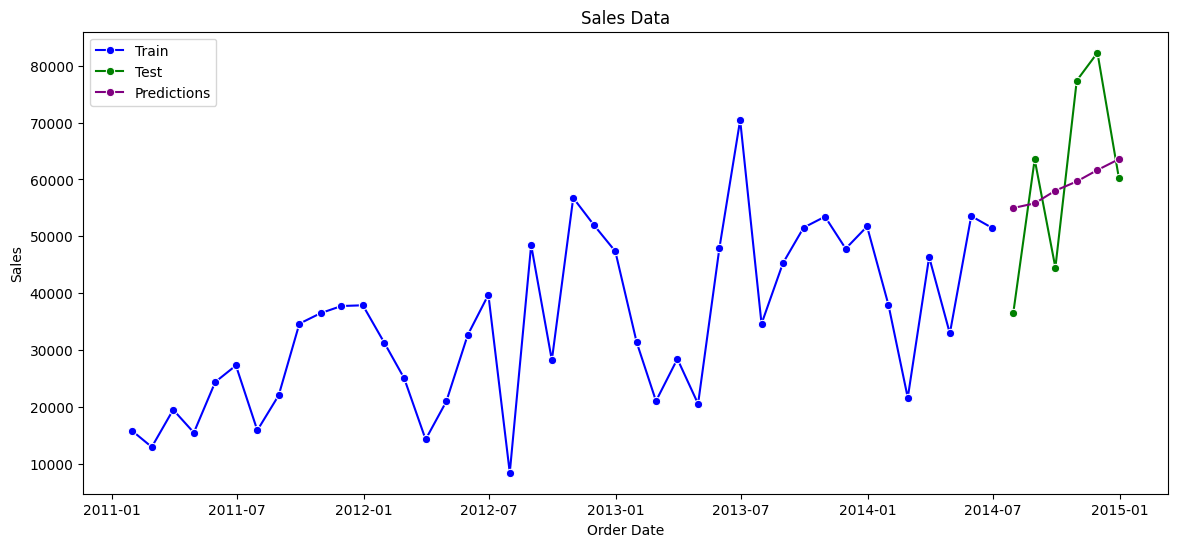

In [63]:
# Plot the time series data with the train-test split and the testing data predictions
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train, x = 'Order Date', y = 'Sales', marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(data = df_test, x = 'Order Date', y = 'Sales', marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = df_pred_ar.index[train_len:], y = df_pred_ar.values[train_len:], marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Sales Data');

## Model Evaluation

The following evaluation metrics are used:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)

In [64]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

In [65]:
# Extract only forecasted values for the test period
test_size = len(df_test)
df_test_preds = df_pred_ar.tail(test_size)

In [66]:
df_test_preds

2014-07-31    54967.060645
2014-08-31    55785.827303
2014-09-30    58022.731914
2014-10-31    59637.129447
2014-11-30    61649.637829
2014-12-31    63553.093882
Freq: ME, dtype: float64

In [67]:
mae_ar = mean_absolute_error(df_test, df_test_preds)
print("MAE :", mae_ar)

MAE : 13560.758610172566


In [68]:
# Root Mean Squared Error
rmse_ar = np.sqrt(mean_squared_error(df_test,df_test_preds))
print("RMSE :", round(rmse_ar, 2))

RMSE : 14915.16


In [69]:
performance_df = pd.DataFrame(index = ['A'],data = {'Model': 'AR', 'RMSE': rmse_ar,'MAE':mae_ar})

#performance_df.set_index('Model', inplace = True)

performance_df

,Model,RMSE,MAE
A,AR,14915.156143,13560.75861


# Part 12: ARIMA Modeling
## Autoregressive Integrated Moving Average
The model is represented as:

ARIMA(p,d,q)

Where:

- p = Autoregressive Order
- d = Differencing Order
- q = Moving Average Order

The ARIMA model parameters are selected using the ACF and PACF plots.

- PACF → Determines p
- Differencing → Determines d
- ACF → Determines q

In [70]:
# Note: Since differencing is integrated into the ARIMA method, we will use 'df_boxcox' instead of 'df_boxcox_diff'
arima_model = ARIMA(df_boxcox, order = (1, 0, 1))
arima_model = arima_model.fit()

In [71]:
arima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   42
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 -24.403
Date:                Wed, 17 Jun 2026   AIC                             56.807
Time:                        11:04:17   BIC                             63.758
Sample:                    01-31-2011   HQIC                            59.355
                         - 06-30-2014                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.3269      0.188     55.042      0.000       9.959      10.695
ar.L1          0.8409      0.198      4.249      0.000       0.453       1.229
ma.L1         -0.5511      0.272     -2.023      0.043      -1.085      -0.017
sigma2         0.1856      0.045      4.157      0.000       0.098       0.273
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 3.87
Prob(Q):                              0.91   Prob(JB):                         0.14
Heteroskedasticity (H):               1.47   Skew:                            -0.66
Prob(H) (two-sided):                  0.48   Kurtosis:                         3.68
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [72]:
arima_model

In [73]:
# Obtain predictions from the ARIMA model for the testing data indices
train_len = 42
test_1 = []
for i in range(42,len(data)):
    test_1.append(i)

print(test_1)
arima_model_preds = arima_model.forecast(len(test_1)+1)
arima_model_preds

[42, 43, 44, 45, 46, 47]


2014-07-31    10.597482
2014-08-31    10.554442
2014-09-30    10.518248
2014-10-31    10.487811
2014-11-30    10.462216
2014-12-31    10.440692
2015-01-31    10.422592
Freq: ME, Name: predicted_mean, dtype: float64

In [74]:
arima_model_preds

2014-07-31    10.597482
2014-08-31    10.554442
2014-09-30    10.518248
2014-10-31    10.487811
2014-11-30    10.462216
2014-12-31    10.440692
2015-01-31    10.422592
Freq: ME, Name: predicted_mean, dtype: float64

In [75]:
# Append the predictions with 'df_boxcox' to prepare the data for inverse transformation
df_boxcox_preds_arima = pd.concat([df_boxcox, arima_model_preds])

In [76]:
df_boxcox_preds_arima

2011-01-31     9.662162
2011-02-28     9.465824
2011-03-31     9.876762
2011-04-30     9.644737
2011-05-31    10.100245
2011-06-30    10.213176
2011-07-31     9.670472
2011-08-31     9.999354
2011-09-30    10.451990
2011-10-31    10.504301
2011-11-30    10.538015
2011-12-31    10.541307
2012-01-31    10.350762
2012-02-29    10.126058
2012-03-31     9.563893
2012-04-30     9.948770
2012-05-31    10.392332
2012-06-30    10.589359
2012-07-31     9.034764
2012-08-31    10.788180
2012-09-30    10.246837
2012-10-31    10.946289
2012-11-30    10.858364
2012-12-31    10.765187
2013-01-31    10.352276
2013-02-28     9.952265
2013-03-31    10.254659
2013-04-30     9.928605
2013-05-31    10.778531
2013-06-30    11.162471
2013-07-31    10.451517
2013-08-31    10.719994
2013-09-30    10.849594
2013-10-31    10.886475
2013-11-30    10.775048
2013-12-31    10.853554
2014-01-31    10.543348
2014-02-28     9.979731
2014-03-31    10.743763
2014-04-30    10.401152
2014-05-31    10.888275
2014-06-30    10

In [77]:
# Reverse the Box-Cox transformation that was done on the data
df_preds_arima = np.exp(df_boxcox_preds_arima)

In [78]:
df_preds_arima

2011-01-31    15711.712500
2011-02-28    12910.858800
2011-03-31    19472.563200
2011-04-30    15440.304600
2011-05-31    24348.972300
2011-06-30    27260.019600
2011-07-31    15842.831700
2011-08-31    22012.236600
2011-09-30    34613.184900
2011-10-31    36472.047000
2011-11-30    37722.603900
2011-12-31    37846.991100
2012-01-31    31280.863500
2012-02-29    24985.688100
2012-03-31    14241.176100
2012-04-30    20926.472100
2012-05-31    32608.621200
2012-06-30    39710.035200
2012-07-31     8389.731600
2012-08-31    48444.797700
2012-09-30    28193.223600
2012-10-31    56743.083300
2012-11-30    51967.014000
2012-12-31    47343.626700
2013-01-31    31328.262000
2013-02-28    20999.737800
2013-03-31    28414.620900
2013-04-30    20508.719700
2013-05-31    47979.600000
2013-06-30    70436.808900
2013-07-31    34596.824700
2013-08-31    45251.643900
2013-09-30    51513.223500
2013-10-31    53448.553200
2013-11-30    47812.778400
2013-12-31    51717.620400
2014-01-31    37924.329600
2

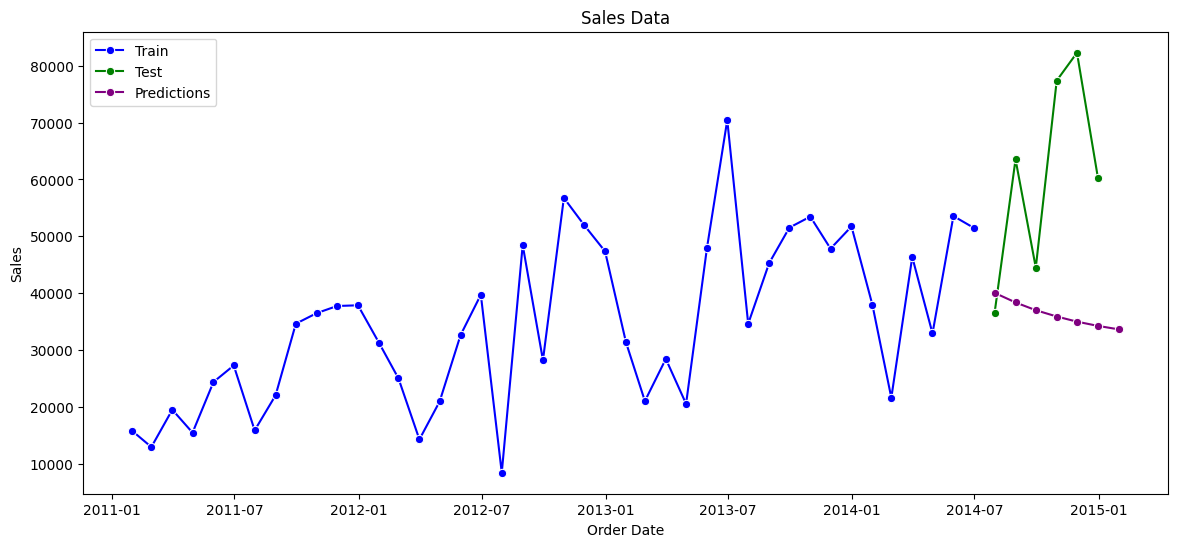

In [79]:
# Plot the time series data with the train-test split and the testing data predictions
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train, x = 'Order Date', y = 'Sales', marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(data = df_test, x = 'Order Date', y = 'Sales', marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = df_preds_arima.index[train_len:], y = df_preds_arima.values[train_len:], marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Sales Data');

In [80]:
# Extract only forecasted values for the test period
test_size = len(df_test)
df_test_preds_arima = df_preds_arima.tail(test_size)

In [81]:
df_test_preds_arima

2014-08-31    38347.390047
2014-09-30    36984.255078
2014-10-31    35875.533221
2014-11-30    34968.945267
2014-12-31    34224.326190
2015-01-31    33610.441278
Freq: ME, dtype: float64

In [82]:
mae_arima = mean_absolute_error(df_test, df_test_preds_arima)
print("MAE :", mae_arima)

MAE : 25686.157202146973


In [83]:
# Root Mean Squared Error
rmse_arima = np.sqrt(mean_squared_error(df_test,df_test_preds_arima))
print("RMSE :", round(rmse_arima, 2))

RMSE : 30556.25


In [84]:
performance_df_temp = pd.DataFrame(index = ['B'],data = {'Model': 'ARIMA', 'RMSE': rmse_arima,'MAE':mae_arima})

#performance_df.set_index('Model', inplace = True)

performance_df = pd.concat([performance_df, performance_df_temp])
performance_df

,Model,RMSE,MAE
A,AR,14915.156143,13560.758610
B,ARIMA,30556.253674,25686.157202


# Part 13: SARIMA Modeling
## Seasonal Autoregressive Integrated Moving Average
SARIMA extends ARIMA by incorporating seasonal components and is represented as:

SARIMA(p,d,q)(P,D,Q,s)

Where:

Non-Seasonal Parameters:
- p = AutoRegressive Order
- d = Differencing Order
- q = Moving Average Order

Seasonal Parameters:
- P = Seasonal AutoRegressive Order
- D = Seasonal Differencing Order
- Q = Seasonal Moving Average Order
- s = Seasonal Period

SARIMA is particularly useful when recurring seasonal patterns are present in the data.

In [85]:
# Import 'SARIMAX' from 'statsmodels' for building autoregressive models
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [86]:
# Note: We know that the seasonality period in the data is 'm = 12'
# Note: Since differencing is integrated into the SARIMA method, we will use 'df_boxcox' instead of 'df_boxcox_diff'
sarima_model = SARIMAX(df_boxcox, order = (1,0,1), seasonal_order = (1,0,1, 12))
sarima_model = sarima_model.fit()

In [87]:
# Obtain predictions from the SARIMA model for the testing data indices
train_len = 42
test_2 = []
for i in range(train_len,len(data)-1):
    test_2.append(i)

print(test_2)
sarima_model_preds = sarima_model.forecast(len(test_2)+1)
sarima_model_preds

[42, 43, 44, 45, 46]


2014-07-31    10.261576
2014-08-31    10.875613
2014-09-30    10.880061
2014-10-31    11.084090
2014-11-30    11.034322
2014-12-31    11.032442
Freq: ME, Name: predicted_mean, dtype: float64

In [88]:
sarima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                   42
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                 -20.933
Date:                            Wed, 17 Jun 2026   AIC                             51.866
Time:                                    11:04:19   BIC                             60.554
Sample:                                01-31-2011   HQIC                            55.050
                                     - 06-30-2014                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9992      0.004    245.238      0.000       0.991       1.007
ma.L1         -0.8403      0.141     -5.957      0.000      -1.117      -0.564
ar.S.L12       0.9792      0.127      7.722      0.000       0.731       1.228
ma.S.L12      -0.7765      0.633     -1.226      0.220      -2.018       0.465
sigma2         0.0953      0.051      1.852      0.064      -0.006       0.196
===================================================================================
Ljung-Box (L1) (Q):                   0.53   Jarque-Bera (JB):                 7.13
Prob(Q):                              0.47   Prob(JB):                         0.03
Heteroskedasticity (H):               0.98   Skew:                            -0.84
Prob(H) (two-sided):                  0.98   Kurtosis:                         4.12
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [89]:
# Append the predictions with 'df_boxcox' to prepare the data for inverse transformation
df_boxcox_preds_sarima = pd.concat([df_boxcox, sarima_model_preds])

In [90]:
# Reverse the Box-Cox transformation that was done on the data
df_preds_sarima = np.exp(df_boxcox_preds_sarima)

In [91]:
df_preds_sarima

2011-01-31    15711.712500
2011-02-28    12910.858800
2011-03-31    19472.563200
2011-04-30    15440.304600
2011-05-31    24348.972300
2011-06-30    27260.019600
2011-07-31    15842.831700
2011-08-31    22012.236600
2011-09-30    34613.184900
2011-10-31    36472.047000
2011-11-30    37722.603900
2011-12-31    37846.991100
2012-01-31    31280.863500
2012-02-29    24985.688100
2012-03-31    14241.176100
2012-04-30    20926.472100
2012-05-31    32608.621200
2012-06-30    39710.035200
2012-07-31     8389.731600
2012-08-31    48444.797700
2012-09-30    28193.223600
2012-10-31    56743.083300
2012-11-30    51967.014000
2012-12-31    47343.626700
2013-01-31    31328.262000
2013-02-28    20999.737800
2013-03-31    28414.620900
2013-04-30    20508.719700
2013-05-31    47979.600000
2013-06-30    70436.808900
2013-07-31    34596.824700
2013-08-31    45251.643900
2013-09-30    51513.223500
2013-10-31    53448.553200
2013-11-30    47812.778400
2013-12-31    51717.620400
2014-01-31    37924.329600
2

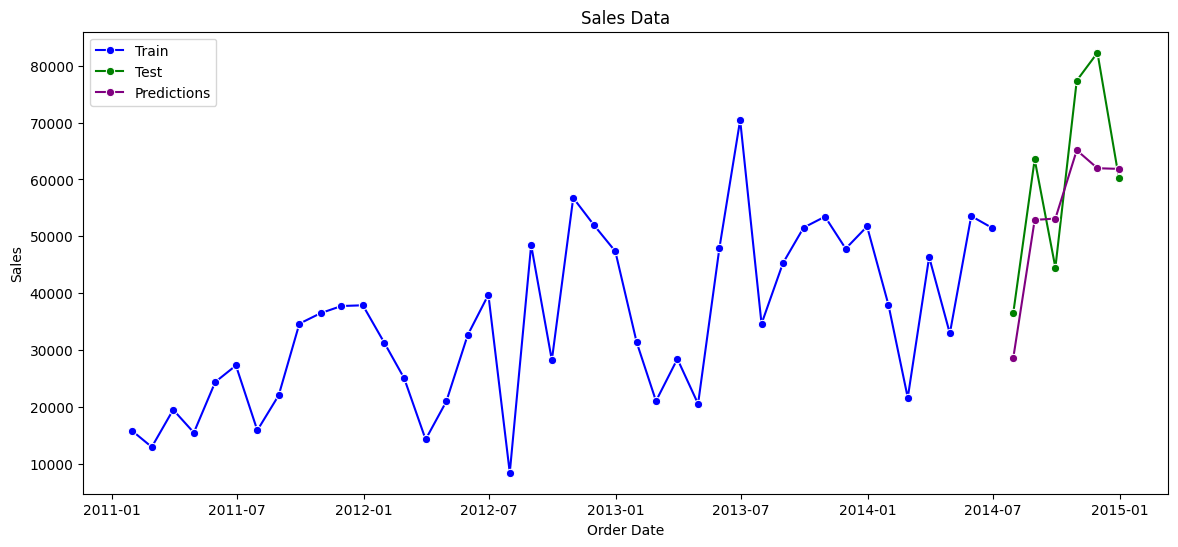

In [92]:
# Plot the time series data with the train-test split and the testing data predictions
plt.figure(figsize = (14, 6))
sns.lineplot(data = df_train, x = 'Order Date', y = 'Sales', marker = 'o', color = 'blue', label = 'Train')
sns.lineplot(data = df_test, x = 'Order Date', y = 'Sales', marker = 'o', color = 'green', label = 'Test')
sns.lineplot(x = df_preds_sarima.index[train_len:], y = df_preds_sarima.values[train_len:], marker = 'o', color = 'purple', label = 'Predictions')
plt.title('Sales Data');

In [93]:
# Extract only forecasted values for the test period
test_size = len(df_test)
df_test_preds_sarima = df_preds_sarima.tail(test_size)

In [94]:
test_size

6

In [95]:
df_test_preds_sarima

2014-07-31    28611.844483
2014-08-31    52871.140224
2014-09-30    53106.863921
2014-10-31    65126.728814
2014-11-30    61964.834522
2014-12-31    61848.415256
Freq: ME, dtype: float64

In [96]:
mae_sarima = mean_absolute_error(df_test, df_test_preds_sarima)
print("MAE :", mae_sarima)

MAE : 10220.599422188341


In [97]:
# Root Mean Squared Error
rmse_sarima = np.sqrt(mean_squared_error(df_test,df_test_preds_sarima))
print("RMSE :", round(rmse_sarima, 2))

RMSE : 11662.17


# Part 14: Model Evaluation & Comparison

In [98]:
performance_df_temp = pd.DataFrame(index = ['C'],data = {'Model': 'SARIMA', 'RMSE': rmse_sarima,'MAE':mae_sarima})

#performance_df.set_index('Model', inplace = True)

performance_df = pd.concat([performance_df, performance_df_temp])
performance_df

,Model,RMSE,MAE
A,AR,14915.156143,13560.758610
B,ARIMA,30556.253674,25686.157202
C,SARIMA,11662.173422,10220.599422


In [99]:
comparison_df = pd.DataFrame({
    'Model': ['AR', 'ARIMA', 'SARIMA'],
    'MAE': [mae_ar, mae_arima, mae_sarima],
    'RMSE': [rmse_ar, rmse_arima, rmse_sarima]
})
comparison_df

,Model,MAE,RMSE
0,AR,13560.758610,14915.156143
1,ARIMA,25686.157202,30556.253674
2,SARIMA,10220.599422,11662.173422


In [100]:
performance_df.sort_values(
    by="RMSE",
    ascending=True
)

,Model,RMSE,MAE
C,SARIMA,11662.173422,10220.599422
A,AR,14915.156143,13560.758610
B,ARIMA,30556.253674,25686.157202


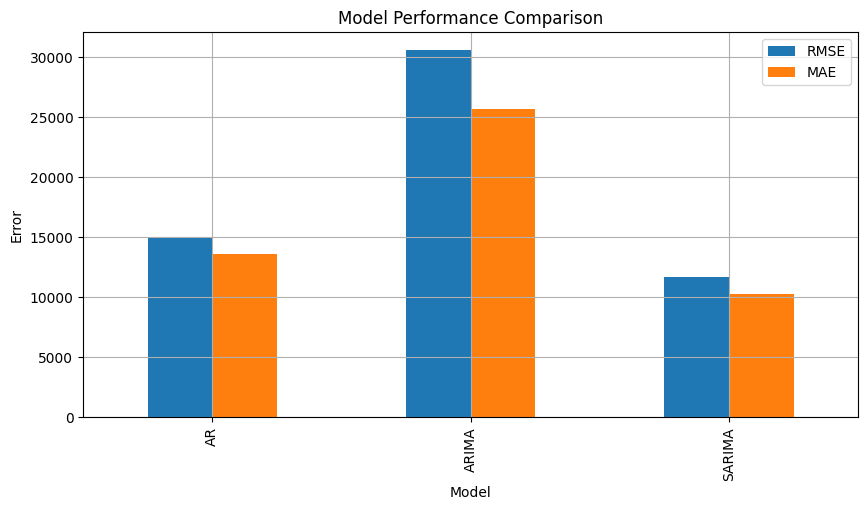

In [102]:
performance_df.set_index("Model").plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Error")
plt.grid(True)
plt.show()

## Interpretation

The model with the lowest RMSE and MAE is considered the best-performing forecasting model.
Based on the evaluation metrics, the selected model will be used for generating business recommendations and future forecasts.

# Part 15: Conclusion

This project analyzed historical retail sales data and developed forecasting models using AR, ARIMA, and SARIMA techniques.

The models were evaluated using forecasting metrics, and the best-performing model was identified for future sales prediction.
The results demonstrate the importance of time series forecasting in supporting data-driven business decisions.